# Librerías

In [67]:
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Conjunto de datos
Se carga el conjunto de datos spam, el cual tiene dos variables, la primera es una etiqueta donde ham es un correo legítimo y spam es un correo no deseado, y la segunda variabe contiene el texto del mensaje.    
Para este conjunto de datos se debe especificar el tipo de codificación para que se puedan leer los datos.   

In [68]:
df = pd.read_csv('spam.csv', encoding = 'latin-1')

# Visualización del conjunto de datos

# Análisis Exploratorio de Datos (EDA)
Se realiza el análisis exploratorio de datos para conocer acerca del comportamoento y de las distribuciones del conjunto de datos.   
Primero, se obtiene la información general.

In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


Se observan los primeros 5 registros

In [70]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Se realiza el conteo de los registos, se hacce utilizando la función shape, de manera que se devuelve una tupla, donde el primer dato corresponde a los registros y el segundo dato a las variables.

In [71]:
df.shape

(5572, 5)

In [72]:
Se hace el conto de los valores nulos.

SyntaxError: invalid syntax (3615053643.py, line 1)

In [73]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

Se hace el conteo de los datos duplicados.

In [74]:
df.duplicated().sum()

np.int64(403)

Se eliminan estos datos duplicados utilizando la función drop_duplicates, dejando como paramétro que se quede solo el primer registro. Se toma la decisión de eliminarlos ya que no representan un porcentaje significativo comparado con el conjunto de datos original.

In [75]:
df = df.drop_duplicates(keep='first')

Se realiza el conteo de datos para cada clase

In [76]:
print(df['v1'].value_counts())

v1
ham     4516
spam     653
Name: count, dtype: int64


Se grafica la distribución de las clases

C:\Users\venss\AppData\Local\Temp\ipykernel_35776\3359229908.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='v1', palette='Set2')


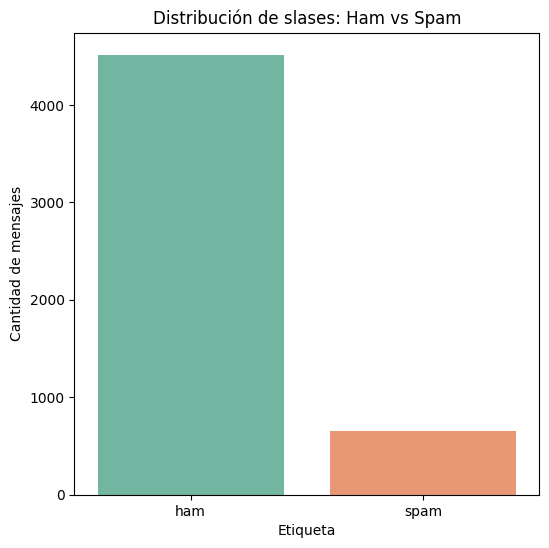

In [77]:
plt.figure(figsize=(6, 6))
sns.countplot(data=df, x='v1', palette='Set2')
plt.title('Distribución de slases: Ham vs Spam')
plt.xlabel('Etiqueta')
plt.ylabel('Cantidad de mensajes')
plt.show()

Se crea una nueva columna para medir la longtud de los textos

In [78]:
df['length'] = df['v2'].apply(len)
df['length']

0       111
1        29
2       155
3        49
4        61
       ... 
5567    161
5568     37
5569     57
5570    125
5571     26
Name: length, Length: 5169, dtype: int64

Se grafica la distribución del tamaño de cada mensaje. De color verde y representados por 0 son aquellos que no son spam, mientras que de color naranja y representado por 1 son aquellos correos de ser spam.

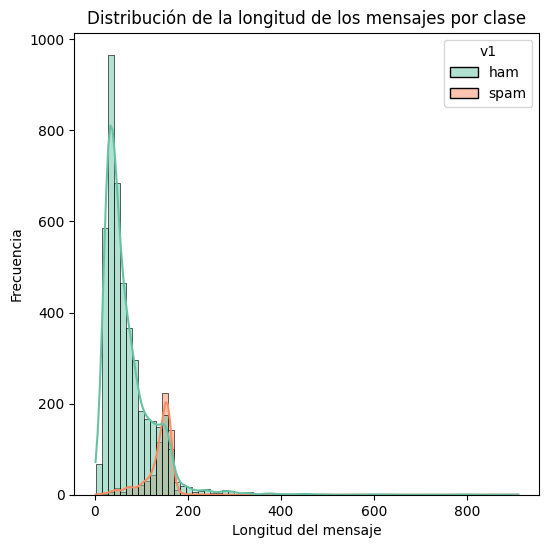

In [79]:
plt.figure(figsize=(6, 6))
sns.histplot(data=df, x='length', hue='v1', bins=70, kde=True, palette='Set2')
plt.title('Distribución de la longitud de los mensajes por clase')
plt.xlabel('Longitud del mensaje')
plt.ylabel('Frecuencia')
plt.show()

# Delimitación del conjunto de datos
Se conserva unicamente la información relevante, es decir, la primer varible que es la etiqueta y la variable de interés, y la segunda varible que tiene el contenido del mensaje.

In [80]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# Conversión de clases

In [81]:
df['label'] = df['label'].map({'ham': 0, 'spam':1})

# Función principal
Se establece una función para poder entrenar el modelo con diferentes tamaños de conjuntos:   
1. Entrenamiento 90% y prueba 10%
2. Entrenamiento 80% y prueba 20%
3. Entrenamiento 70% y prueba 30%

Después, se hace la conversión del conjunto de datos en vectores, para esto se usa la función CountVecorizer() que convierte documentos de texto a recuentos de palabras, es decir, tokens, de manera que se crea una representación de bolsa de palabras. Se hace la transformación del texto a la matriz para el conjunto de entrenamiento y de prueba.   

Se aplica el modelo Naive Bayes Multinomial, es decir, clasificador bayesiano ingenuo, el cual se utiliza para la clasificación de textos según la frecuencia de las palabras. Se usa la siguiente formula:   
$$P(X) = \frac{n!}{n_1!, n_2!,...,n_m!}p_1^{n_1}, p_2^{n_2},...,p_m^{n_m}$$
Donde:  
$n$: Cantidad total de ensayos.     
$n_i$: Recuento de ocurrencias para i.    
$p_i$: Probabilidad del resultado i.   
Finalmente, se obtiene la precisión del modelo, sensibilidad, puntuación f1, soporte y la matriz de confusión.

In [92]:
def entrenar(df):
    tam = [0.1, 0.2, 0.3]

    for size in tam:
        print(f'El tamaño del conjunto de prueba es: {size}')

        #División del conjunto de entrenamiento y prueba
        X_train, X_test, y_train, y_test = train_test_split(df['message'], df['label'], test_size = size, random_state = 7)

        #Conversión del conjunto de datos en vectores
        vectorizer = CountVectorizer() #Transformación a bolsa de palabras
        X_train_vec = vectorizer.fit_transform(X_train) #Se transforma el conjunto de entrenamiento
        X_test_vec = vectorizer.transform(X_test) #Se transforma el conjunto de prueba

        #Modelo
        model = MultinomialNB() #Se genera la clase para el modelo clasificador bayesiano ingenuo
        model.fit(X_train_vec, y_train)

        #Predicciones
        y_pred = model.predict(X_test_vec)

        #Evaluación del modelo
        print('Precisión del modelo:', accuracy_score(y_test, y_pred))
        print('\nReporte de clasificación')
        print(classification_report(y_test, y_pred, target_names = ['Ham', 'Spam']))

        #Matriz de confusión
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Ham', 'Spam'])
        plt.figure(figsize = (6, 6))
        disp.plot(cmap = 'Blues', values_format = 'd')
        plt.title('Matriz de confusión - Clasificación de SPAM')
        plt.show()

El tamaño del conjunto de prueba es: 0.1
Precisión del modelo: 0.9825918762088974

Reporte de clasificación
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       448
        Spam       0.95      0.91      0.93        69

    accuracy                           0.98       517
   macro avg       0.97      0.95      0.96       517
weighted avg       0.98      0.98      0.98       517



<Figure size 600x600 with 0 Axes>

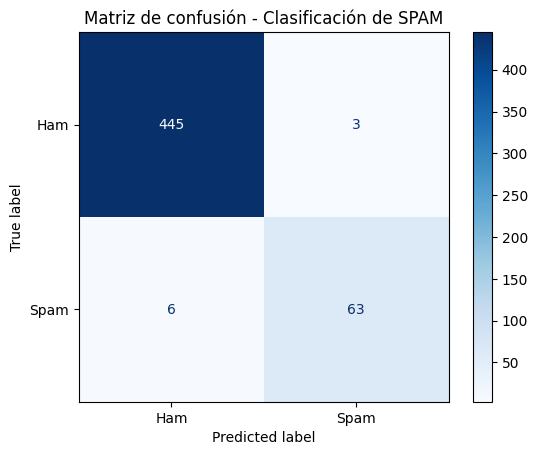

El tamaño del conjunto de prueba es: 0.2
Precisión del modelo: 0.9825918762088974

Reporte de clasificación
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       886
        Spam       0.96      0.92      0.94       148

    accuracy                           0.98      1034
   macro avg       0.97      0.96      0.96      1034
weighted avg       0.98      0.98      0.98      1034



<Figure size 600x600 with 0 Axes>

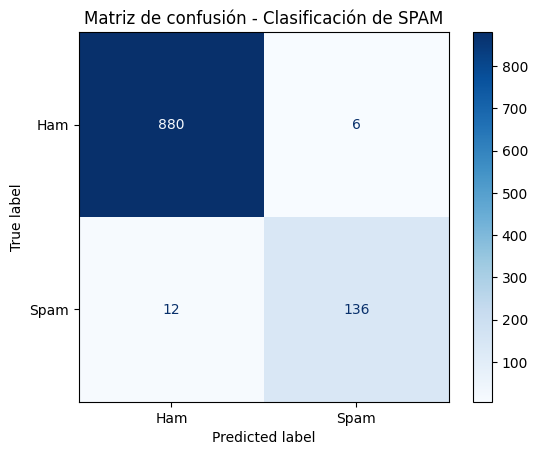

El tamaño del conjunto de prueba es: 0.3
Precisión del modelo: 0.9793681495809156

Reporte de clasificación
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99      1341
        Spam       0.95      0.89      0.92       210

    accuracy                           0.98      1551
   macro avg       0.97      0.94      0.95      1551
weighted avg       0.98      0.98      0.98      1551



<Figure size 600x600 with 0 Axes>

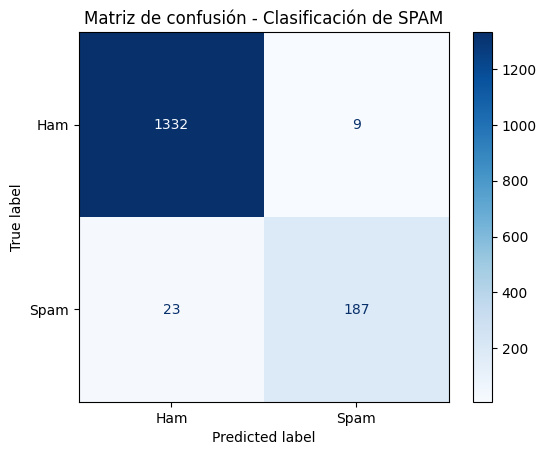

In [93]:
entrenar(df)

# Conclusiones
Se conlcuye que, el modelo con mejores métricas fue el que utilizó 90% entrenamiento y 10$ prueba, pues se tuvo una precisión del 98% y muy pocos errores en la matriz de confusión, además una sensibilidad de 99% para clasificar los correos normales y del 91% para clasificar a los correos spam. 